In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102739_selected_features(2nd).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Mounted at /content/drive
Dataset loaded: (1025, 13)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,2.179817,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,0


Explained variance ratio: [0.23056113 0.12485175]


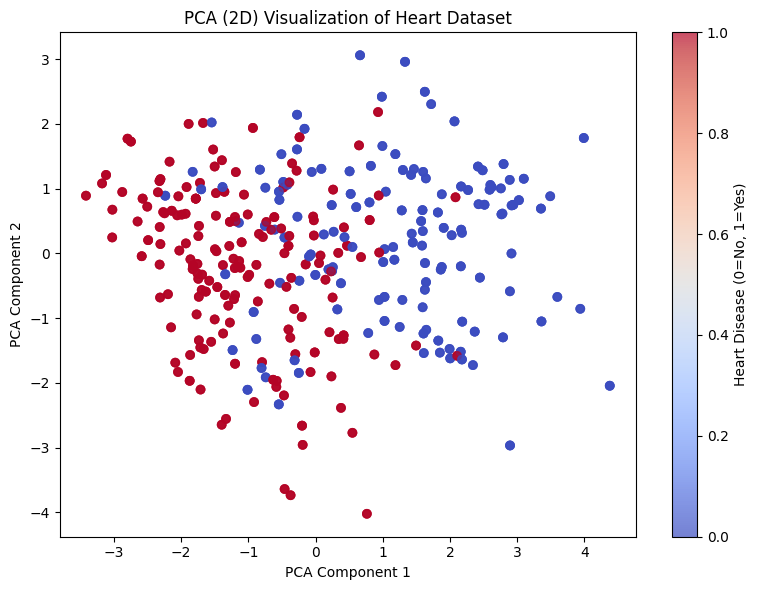

In [2]:
# Dimensionality Reduction (PCA 2 Components)
# Numeric features only (exclude target)
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']

# Standardize features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Plot PCA 2D
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("PCA (2D) Visualization of Heart Dataset")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Heart Disease (0=No, 1=Yes)")
fig.tight_layout()
plt.show()

In [3]:
# Define plot save folder
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/dimension_reduction")
os.makedirs(SAVE_FOLDER, exist_ok=True)

# Save plot
plot_path = os.path.join(SAVE_FOLDER, "pca_2d_visualization.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("PCA plot saved to:", plot_path)

PCA plot saved to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/dimension_reduction/pca_2d_visualization.png


In [4]:
# Updates .csv file save
df_final = df.copy()
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102748_dimensionality_reduction(3rd).csv")
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
df_final.to_csv(PROC_PATH, index=False)
print("Saved dataset with original features only to:", PROC_PATH)

Saved dataset with original features only to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102748_dimensionality_reduction(3rd).csv
